# Configurable fine-tune of the 2d+3d MLP

`TARGET_LETTERS` selects A–Z classes and defaults to all letters. `INCLUDE_NONE` selects
the learning mode: `False` keeps the pretrained 26-class head for ordinary fine-tuning;
`True` expands it to A–Z plus `none` for transfer learning. Every numbered still
**1–100** is loaded from each selected `fine-tune/<hand>/<class>/` folder, giving 100
images per class per hand. Validation and test remain A–Z, so a `none` prediction there
counts as an error.

Every base, fine-tune, validation and test image is normalized independently: its 42
image x/y values are min-max normalized to `[0,1]`, its 63 wrist-relative world values
are separately min-max normalized to `[0,1]`, then the two blocks are concatenated.
No dataset-wide span is measured or reused.

The geometric exception is **no G, H, P, Q turn** for the fine-tune, validation and test
captures. That correction exists only for public source folders that sign those four
letters end for end. These captures sign them correctly.

Every selected 1–100 image that passes the training quality gates is used for
fine-tuning—none is held out. Model selection uses the independent balanced
`validation_set/` capture cached in `keypoints.npz`, with the same 0.5 palm/presence
gates as `experiment_mlp.ipynb`. The final `signlanguagetestdata/` capture remains
untouched until the last cell. There is no cross-validation or hyperparameter search.

The scan cache, weights, and run file are tagged automatically: `ALL_1-100` for standard
fine-tuning and `ALL_NONE_1-100` when transfer learning includes `none`; targeted letter
subsets follow the same rule. Different modes cannot overwrite one another or older
51–100 artifacts.

The base weights live in `weights/2d+3d_mlp.pt`, where `experiment_mlp.ipynb` leaves
them.

In [ ]:
# --- Fine-tune configuration: edit settings only here ------------------------------
import string

# Data/classes
FEATURES = "2d+3d"                         # this notebook supports the 105-D base model
TARGET_LETTERS = tuple(string.ascii_uppercase)  # e.g. tuple("NTUZDX")
INCLUDE_NONE = True                        # False=26-class fine-tune; True=27-class transfer
VALID_IMAGE_NUMBERS = range(1, 101)        # numbered stills selected from each folder

# Validation/test detector gates
PALM_MIN = 0.5
PRESENCE_MIN = 0.5

# Fine-tune training-data quality gates
PALM = (0.8, 1.0)
CONFIDENCE = (0.9, 1.0)
HAND = (0.0, 0.3)                          # distance from handedness 0 or 1

# Optimization (hidden layers are read from the pretrained checkpoint and must match it)
DROPOUT = 0.3
BATCH_SIZE = 128
FT_LR = 1e-4
FINETUNE_EPOCHS = 300
LR_DECAY = 0.0
LR_PATIENCE = 10_000
EARLY_STOP = 10_000
FINETUNE_SEED = 0

# Cache/extraction and preview
RESUME_CACHE = True
SCAN_BATCH = 256
SHOW = 6

In [21]:
# --- keypoints.npz, walked exactly as experiment_mlp.ipynb walks it -----------------
# This is that notebook's road for FEATURES="2d+3d", reproduced rather than changed:
# every image independently normalizes its 2D and 3D blocks before they are joined.
# The same function below is reused for base train/val, fine-tune and independent test.
from pathlib import Path

import numpy as np

KEYPOINTS = Path("keypoints.npz")       # written by extract_keypoints.ipynb
IN_DIM = 105
FINGERS = [(0, 1, 2, 3, 4), (0, 5, 6, 7, 8), (0, 9, 10, 11, 12),
           (0, 13, 14, 15, 16), (0, 17, 18, 19, 20)]

# Folders that sign these letters end for end. Turning a hand around is a half turn
# about the vertical axis, so x and z both change sign while y stays put -- that keeps
# it the same hand. A mirror, which flips x alone, would turn a right hand into a left.
FACING_LETTERS = "GHPQ"
FACING_FOLDERS = ("2", "4", "6", "9", "10", "12", "16")

_z = np.load(KEYPOINTS)
CLASSES = [str(c) for c in _z["classes"]]
val_presence, val_handed, val_labels, val_palm, val_left = (
    _z["val_presence"], _z["val_handed"], _z["val_labels"],
    _z["val_palm"], _z["val_left"])


def unrotate(kp, world, deg):
    """Cached kp, world -> the same hands at the tilt they were held at.

    The palm detector spun every crop by deg to stand its hand up, so the cached
    landmarks lost that pose; turning them back by deg puts it into the numbers. kp is
    a fraction of the crop, so it turns about the crop centre 0.5; world shares the
    crop's axes and turns about its own origin, which by linearity is the same as
    turning the wrist-relative offsets built below. z is the rotation axis in both.
    """
    kp, world = kp.copy(), world.copy()
    rad = np.radians(deg)
    c, s = np.cos(rad), np.sin(rad)
    turn = np.stack([np.stack([c, -s], -1), np.stack([s, c], -1)], -2)
    kp[..., :2] = 0.5 + np.einsum("nij,nkj->nki", turn, kp[..., :2] - 0.5)
    world[..., :2] = np.einsum("nij,nkj->nki", turn, world[..., :2])
    return kp, world


def turn_around(kp, world, labels, subset):
    """Half turn about the vertical axis, for the folders that sign GHPQ backwards."""
    folder = np.array([s.split("/")[0] for s in subset])
    hit = (np.isin(labels, [CLASSES.index(c) for c in FACING_LETTERS])
           & np.isin(folder, FACING_FOLDERS))
    kp, world = kp.copy(), world.copy()
    kp[hit, :, 0] = 1.0 - kp[hit, :, 0]     # kp x is a fraction of the crop, so it
    kp[hit, :, 2] *= -1.0                   # turns about 0.5; its z is 0 at the wrist
    world[hit, :, 0] *= -1.0
    world[hit, :, 2] *= -1.0
    return kp, world, hit


def mirror(kp, world, handed):
    """Left hands folded onto right, so one sign is one shape. Only x moves."""
    flip = handed < 0.5
    kp, world = kp.copy(), world.copy()
    kp[flip, :, 0] = 1.0 - kp[flip, :, 0]
    world[flip, :, 0] *= -1.0
    return kp, world


# Only public training folders receive the G/H/P/Q facing correction. The independent
# validation capture was filmed correctly and follows the same path as the test set.
base = {}
for _split in ("train", "val"):
    _kp, _w = unrotate(_z[f"{_split}_kp"], _z[f"{_split}_world"], _z[f"{_split}_deg"])
    _before = _w                # the world landmarks as cached, for the check below
    if _split == "train":
        _kp, _w, _hit = turn_around(
            _kp, _w, _z["train_labels"], _z["train_subset"])
    else:
        _hit = np.zeros(len(_kp), dtype=bool)
    _kp, _w = mirror(_kp, _w, _z[f"{_split}_handed"])
    base[_split] = {"kp": _kp, "world": _w - _w[:, :1, :],
                    "turned": _hit, "before": _before}


def minmax_per_sample(values):
    """Flatten each image and independently map its finite values to [0,1]."""
    flat = np.asarray(values, dtype=np.float32).reshape(len(values), -1)
    low = flat.min(axis=1, keepdims=True)
    width = flat.max(axis=1, keepdims=True) - low
    return np.divide(flat - low, width, out=np.full_like(flat, 0.5),
                     where=np.isfinite(width) & (width > 0))


def features(kp, world):
    """-> (N, 105): separately per-image normalized 2D and 3D blocks."""
    xy = minmax_per_sample(kp[..., :2])
    world3d = minmax_per_sample(world)
    return np.concatenate([xy, world3d], axis=1).astype(np.float32)


def assert_per_sample_normalized(X):
    """Each 2D/3D block must span [0,1], or be the neutral constant 0.5 block."""
    assert X.shape[1] == IN_DIM and np.isfinite(X).all()
    for block in (X[:, :42], X[:, 42:]):
        neutral = np.all(block == 0.5, axis=1)
        scaled = (np.isclose(block.min(axis=1), 0.0)
                  & np.isclose(block.max(axis=1), 1.0))
        assert np.all(neutral | scaled)


_probe = minmax_per_sample(np.array([[[-3.0, 0.0, 3.0]], [[7.0, 7.0, 7.0]]]))
assert np.allclose(_probe[0], (0.0, 0.5, 1.0)) and np.all(_probe[1] == 0.5)

base_val_scored = np.isfinite(val_presence)
base_val_sure = (base_val_scored & (val_palm >= PALM_MIN)
                 & (val_presence >= PRESENCE_MIN))
X_base_train = features(base["train"]["kp"], base["train"]["world"])
X_base_val = np.where(
    base_val_scored[:, None], features(base["val"]["kp"], base["val"]["world"]), 0.5
).astype(np.float32)
y_base_train, y_base_val = _z["train_labels"], val_labels
assert_per_sample_normalized(X_base_train)
assert_per_sample_normalized(X_base_val)
assert base_val_sure.any(), "no validation_set frames clear the configured gates"


# Turning is not flipping, and the difference only shows in 3d: a half turn is det +1
# and leaves the hand the same hand, a mirror is det -1 and swaps it for the other one.
# The signed volume at the wrist is that chirality, so it has to survive the turn and
# reverse for exactly the left hands the fold mirrored, and for nothing else.
def chirality(a):
    u, v, t = a[:, 5] - a[:, 0], a[:, 17] - a[:, 0], a[:, 9] - a[:, 0]
    return np.sign(np.einsum("ni,ni->n", np.cross(u, v), t))


assert np.array_equal(chirality(base["train"]["world"]),
                      np.where(_z["train_handed"] < 0.5, -1, 1)
                      * chirality(base["train"]["before"]))

print(f"base run {FEATURES!r} -> {IN_DIM} dims from {KEYPOINTS}")
print(f"  {len(X_base_train):,} filtered public training rows; "
      f"{base['train']['turned'].sum():,} turned around ({FACING_LETTERS})")
print(f"  validation_set {len(X_base_val):,} rows; {base_val_sure.sum():,} clear "
      f"palm {PALM_MIN} and presence {PRESENCE_MIN}; no facing correction")
print("  each image: x/y -> [0,1], world x/y/z -> [0,1], then concatenate")

base run '2d+3d' -> 105 dims from keypoints.npz
  401,783 filtered public training rows; 15,451 turned around (GHPQ)
  validation_set 3,744 rows; 3,674 clear palm 0.5 and presence 0.5; no facing correction
  each image: x/y -> [0,1], world x/y/z -> [0,1], then concatenate


In [22]:
# --- The test capture, and the two gates every number below is quoted at -------------
# Untouched from experiment_mlp.ipynb: the same frames, the same per-image normalization,
# no facing fix (this capture signs GHPQ the right way round), and handedness from the
# landmark net rather than the folder. jazz rejects with `confidence < threshold`, so
# >= is the comparison that matches it, and the gates are a chain: presence is only
# asked about a frame a palm was found in. Both are quoted out of every frame filmed.
test_y, test_left = _z["test_labels"], _z["test_left"]
test_presence, test_handed, test_palm = (
    _z["test_presence"], _z["test_handed"], _z["test_palm"])

te_kp, te_w = unrotate(_z["test_kp"], _z["test_world"], _z["test_deg"])
te_kp, te_w = mirror(te_kp, te_w, test_handed)
te_w -= te_w[:, :1, :]
# Every valid frame gets its own 2D min/max and its own 3D min/max. The one frame that
# would not decode gets the neutral all-0.5 vector rather than influencing another row.
test_scored = np.isfinite(test_presence)
X_test = np.where(test_scored[:, None], features(te_kp, te_w), 0.5).astype(np.float32)
assert_per_sample_normalized(X_test)

found = test_palm >= PALM_MIN
sure = found & (test_presence >= PRESENCE_MIN)
assert X_test.shape == (len(test_y), IN_DIM) and np.isfinite(X_test).all()
# Folder and net are two independent readings of the same thing, so agreement says the
# folders are named the way round they look; swapped folders would score near zero.
assert (test_left == (test_handed < 0.5))[sure].mean() > 0.9, "left/ and right/ swapped"

print(f"X_test {X_test.shape}   {np.bincount(test_y).min()} frames of every letter, "
      f"left and right")
print(f"  palm found     {found.mean():7.2%} of all frames")
print(f"  hand confirmed {sure.mean():7.2%} of all frames")

X_test (3744, 105)   144 frames of every letter, left and right
  palm found      92.95% of all frames
  hand confirmed  87.26% of all frames


In [23]:
# --- The new capture: fine-tune/<hand>/<LETTER>/<LETTER><n>.jpg ----------------------
# Stills, not video frames, so every selected 1-100 image is considered. After the
# training quality gates, every surviving row is used for fine-tuning; validation comes
# only from the independent validation_set cached in keypoints.npz.
import re
import string
from collections import Counter

FINETUNE_ROOT = Path("fine-tune")
ALL_LETTERS = tuple(string.ascii_uppercase)
NONE_CLASS = "none"

if not TARGET_LETTERS or len(TARGET_LETTERS) != len(set(TARGET_LETTERS)):
    raise ValueError("TARGET_LETTERS must contain unique uppercase letters")
if not set(TARGET_LETTERS) <= set(ALL_LETTERS):
    raise ValueError(f"invalid TARGET_LETTERS: {TARGET_LETTERS}")
MODEL_CLASSES = (*ALL_LETTERS, NONE_CLASS) if INCLUDE_NONE else ALL_LETTERS
SELECTED_CLASSES = (*TARGET_LETTERS, NONE_CLASS) if INCLUDE_NONE else TARGET_LETTERS
SELECTED_CLASS_SET = set(SELECTED_CLASSES)

# Consume the configured numbered stills in every selected class-hand folder.
IMAGES_PER_CLASS_PER_HAND = len(VALID_IMAGE_NUMBERS)
_LETTER_TAG = "ALL" if TARGET_LETTERS == ALL_LETTERS else "".join(TARGET_LETTERS)
TARGET_TAG = f"{_LETTER_TAG}{'_NONE' if INCLUDE_NONE else ''}_1-100"
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
CLASS_TO_IDX = {name: i for i, name in enumerate(MODEL_CLASSES)}
TARGET_CLASS_INDICES = np.array([CLASS_TO_IDX[name] for name in SELECTED_CLASSES])


def image_number(path):
    """Trailing integer in `N51.jpg` -> 51; files without one are not selected."""
    match = re.search(r"(\d+)$", path.stem)
    return int(match.group(1)) if match else None


def images_in(folder):
    """Selected 1-100 image files directly inside `folder`, in stable order."""
    selected = []
    for path in folder.iterdir():
        number = image_number(path)
        if (path.suffix.lower() in IMAGE_EXTS and not path.name.startswith("._")
                and number in VALID_IMAGE_NUMBERS):
            selected.append(path)
    return sorted(selected)


def capture():
    """Selected `(path, class, fine-tune/<hand>)` rows for fine-tune/transfer training."""
    for hand in ("left", "right"):
        for folder in sorted(p for p in (FINETUNE_ROOT / hand).iterdir() if p.is_dir()):
            name = NONE_CLASS if folder.name.lower() == NONE_CLASS else folder.name.upper()
            if name in SELECTED_CLASS_SET:
                for image in images_in(folder):
                    yield image, name, f"fine-tune/{hand}"


ft_samples = list(capture())
_per = Counter((label, subset) for _, label, subset in ft_samples)
assert len(_per) == 2 * len(SELECTED_CLASSES), (
    f"{len(_per)} selected class-hand folders, wanted {2 * len(SELECTED_CLASSES)}")
assert set(_per.values()) == {IMAGES_PER_CLASS_PER_HAND}, (
    f"wanted {IMAGES_PER_CLASS_PER_HAND} images per selected class per hand, got "
    f"{min(_per.values())}-{max(_per.values())}")
assert len(ft_samples) == 2 * len(SELECTED_CLASSES) * IMAGES_PER_CLASS_PER_HAND

_mode = "27-class transfer learning" if INCLUDE_NONE else "26-class fine-tuning"
print(f"{len(ft_samples):,} selected stills for {_mode}: {', '.join(SELECTED_CLASSES)}, "
      f"numbers {VALID_IMAGE_NUMBERS.start}-{VALID_IMAGE_NUMBERS.stop - 1}")
print(f"  {min(_per.values())}-{max(_per.values())} per selected class per hand")
print("  per class: " + "  ".join(
    f"{name}={_per[(name, 'fine-tune/left')] + _per[(name, 'fine-tune/right')]}"
    for name in SELECTED_CLASSES))

5,400 selected stills for 27-class transfer learning: A, B, C, D, E, F, G, H, I, J, K, L, M, N, O, P, Q, R, S, T, U, V, W, X, Y, Z, none, numbers 1-100
  100-100 per selected class per hand
  per class: A=200  B=200  C=200  D=200  E=200  F=200  G=200  H=200  I=200  J=200  K=200  L=200  M=200  N=200  O=200  P=200  Q=200  R=200  S=200  T=200  U=200  V=200  W=200  X=200  Y=200  Z=200  none=200


In [24]:
# --- Stage 1: palm detection -> rotated hand ROI ------------------------------------
# Copied unchanged from extract_keypoints.ipynb, which is the source of truth for it.
# The 192 detector locates the palm; its box plus two of its keypoints define a square
# ROI, rotated hand-up, exactly as jazz's GetHandRoiFromPalm builds it.
import math

import cv2
import torch

IMG_SIZE = 224
DET_SIZE = 192
PALM_PAD = 0.3          # shrink inside the detector canvas; 0.0/0.15/0.3 measured
#                         77% / 83% / 86% detection, flat past 0.3
ROI_SCALE = 3.0                 # jazz HandDetectionConfig.roiSizeMultipleOfPalm
ROI_OFFSET = 0.33               # jazz HandDetectionConfig.roiOffsetFromPalm
UPRIGHT = (0.0, -1.0)           # jazz HandPoseDetectionEngine.uprightVec
BRANCHES = (1152, 864)          # anchors per branch; batched output is regrouped on these
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("torch", torch.__version__, "| cuda:", torch.cuda.is_available(),
      "| opencv", cv2.__version__)


def ssd_anchors(input_size=DET_SIZE, strides=(8, 16, 16, 16), offset=0.5):
    """The 2016 SsdAnchorsCalculator centres the palm boxes are regressed against."""
    anchors, n, layer = [], len(strides), 0
    while layer < n:
        last, per_cell = layer, 0
        while last < n and strides[last] == strides[layer]:
            per_cell += 2                  # one aspect ratio + one interpolated scale
            last += 1
        fm = math.ceil(input_size / strides[layer])
        for y in range(fm):
            for x in range(fm):
                anchors += [((x + offset) / fm, (y + offset) / fm)] * per_cell
        layer = last
    return np.array(anchors, np.float32)


_DETECTOR = None


def palm_detector():
    """The TorchScript detector, loaded once onto the GPU (or CPU) and reused."""
    global _DETECTOR
    if _DETECTOR is None:
        _DETECTOR = torch.jit.load(
            "_hand_models/palm_detection_192_full.pt").to(DEVICE).eval()
    return _DETECTOR


def letterbox(bgr, size, pad=0.0):
    """Aspect-preserving fit into a size x size canvas, shrunk by `pad`.

    The anchors only cover boxes up to ~75% of the frame, so a hand that fills a
    tight crop stays invisible to the detector until it is padded down.
    """
    h, w = bgr.shape[:2]
    s = size / (1.0 + pad) / max(h, w)
    nw, nh = max(1, round(w * s)), max(1, round(h * s))
    canvas = np.zeros((size, size, 3), np.uint8)
    ox, oy = (size - nw) // 2, (size - nh) // 2
    canvas[oy:oy + nh, ox:ox + nw] = cv2.resize(bgr, (nw, nh),
                                                interpolation=cv2.INTER_AREA)
    return canvas, s, ox, oy


def palm_input(bgr):
    """The 192 tensor for one image, plus what is needed to map results back to it."""
    canvas, scale, ox, oy = letterbox(bgr, DET_SIZE, PALM_PAD)
    # Resize/warp/crop are per-channel, so channel order only matters here, at the
    # model boundary. Converting the 192 canvas is cheaper than the full image.
    return (cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0,
            scale, ox, oy)


def regroup(flat, n):
    """(1, n*2016, C) branch-major -> (n, 2016, C) back on the host."""
    parts, off = [], 0
    for size in BRANCHES:
        parts.append(flat[0, off:off + n * size].reshape(n, size, -1))
        off += n * size
    return torch.cat(parts, 1).cpu().numpy()


def palm_batch(bgrs):
    """Stage 1 over a list of images -> (N, 5) of score, cx, cy, side, degrees."""
    prepared = [palm_input(b) for b in bgrs]
    x = torch.from_numpy(np.stack([p[0] for p in prepared])).to(DEVICE)
    with torch.no_grad():
        outs = palm_detector()(x)
    # Picked by trailing dim rather than position: 18 box floats and one logit each.
    boxes = regroup(next(t for t in outs if t.shape[-1] == 18), len(bgrs))
    logits = regroup(next(t for t in outs if t.shape[-1] == 1), len(bgrs))[..., 0]
    anchors = ssd_anchors()             # once per batch: 0.7 ms, and the same every time
    return np.array([decode_palm(b, lg, anchors, *p[1:])
                     for b, lg, p in zip(boxes, logits, prepared)], np.float32)


def decode_palm(boxes, logits, anchors, scale, ox, oy):
    """Winning anchor -> (score, cx, cy, side, degrees) in original-image pixels."""
    best = int(logits.argmax())                       # sigmoid is monotonic
    score = 1.0 / (1.0 + math.exp(-float(np.clip(logits[best], -100, 100))))
    b, (ax, ay) = boxes[best], anchors[best]

    def to_px(u, v):                                  # canvas-normalised -> image px
        return ((u * DET_SIZE - ox) / scale, (v * DET_SIZE - oy) / scale)

    cx, cy = to_px(b[0] / DET_SIZE + ax, b[1] / DET_SIZE + ay)
    box_w = b[2] / scale                              # jazz sizes the ROI off width
    # GetHandRoiFromPalm: orientation is middle-finger MCP minus thumb CMC, turned
    # onto UPRIGHT, then the box centre slides along that vector by 0.33 * width.
    mx, my = to_px(b[8] / DET_SIZE + ax, b[9] / DET_SIZE + ay)     # keypoint 2
    tx, ty = to_px(b[14] / DET_SIZE + ax, b[15] / DET_SIZE + ay)   # keypoint 5
    vx, vy = mx - tx, my - ty
    norm = math.hypot(vx, vy) or 1.0
    hx, hy = vx / norm, vy / norm

    dot = max(-1.0, min(1.0, hx * UPRIGHT[0] + hy * UPRIGHT[1]))
    deg = (math.degrees(math.acos(dot))
           * (1.0 if UPRIGHT[0] * hy - UPRIGHT[1] * hx > 0 else -1.0))
    cx += hx * ROI_OFFSET * box_w
    cy += hy * ROI_OFFSET * box_w
    return score, cx, cy, box_w * ROI_SCALE, deg


def crop_roi(bgr, cx, cy, side, deg, size=IMG_SIZE):
    """The ROI square as a size x size RGB image: one warp does rotate+scale+shift."""
    m = cv2.getRotationMatrix2D((cx, cy), deg, size / side)
    m[0, 2] += size / 2 - cx
    m[1, 2] += size / 2 - cy
    warped = cv2.warpAffine(bgr, m, (size, size), flags=cv2.INTER_LINEAR)
    return cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

torch 2.13.0+cu130 | cuda: True | opencv 4.13.0


In [25]:
# --- Stage 2: the crops -> 21 hand keypoints, and the targeted capture cache ----------
# jazz's default landmark net, batched on GPU, also unchanged from
# extract_keypoints.ipynb. Both stages scan only TARGET_LETTERS' fixed 1-100 paths.
# A selection-tagged cache preserves prior scans; its key includes the exact paths.
import hashlib

from tqdm.auto import tqdm

FINETUNE_NPZ = Path(f"finetune_keypoints_{TARGET_TAG}.npz")

_LANDMARKER = None


def landmarker():
    """The TorchScript landmark net, loaded once onto the GPU (or CPU) and reused."""
    global _LANDMARKER
    if _LANDMARKER is None:
        _LANDMARKER = torch.jit.load(
            "_hand_models/hand_landmark_224_full.pt").to(DEVICE).eval()
    return _LANDMARKER


def landmarks_of(images):
    """(N, 3, 224, 224) in [0,1] -> keypoints, world, presence, raw handedness.

    Head order is the MediaPipe one the onnx declares and hand-pose's loader confirms:
    Identity, Identity_1, Identity_2, Identity_3 = landmarks, presence, handedness,
    world. Both coordinate heads keep the scale hand-pose baked in: kp is 0-1 of the
    crop, world is xyz_normalized * 13. Normalized downstream.
    """
    with torch.no_grad():
        out = landmarker()(images.permute(0, 2, 3, 1).to(DEVICE))   # the net wants NHWC
    return (out[0].reshape(-1, 21, 3).cpu().numpy(),
            out[3].reshape(-1, 21, 3).cpu().numpy(),
            out[1].reshape(-1).cpu().numpy(),
            out[2].reshape(-1).cpu().numpy())


def scan_palms(paths):
    """Stage 1 over a path list -> (N, 5). An unreadable image keeps its zero row, so
    its side of 0 drops it out of stage 2 rather than crashing it."""
    out = np.zeros((len(paths), 5), np.float32)
    for at in tqdm(range(0, len(paths), SCAN_BATCH), desc="palm scan", unit="batch"):
        images, rows = [], []
        for i, p in enumerate(paths[at:at + SCAN_BATCH]):
            image = cv2.imread(str(p))
            if image is not None:
                images.append(image)
                rows.append(at + i)
        if images:
            out[rows] = palm_batch(images)
    return out


def scan_landmarks(paths, rois):
    """Stage 2 over the same list -> kp, world, presence, handed, in row order.

    `rois` is (N, 4) of cx, cy, side, degrees, which is what one crop takes.

    One decode and one warp per image, then one forward pass per batch. The crop is
    the detector's upright one, which is the only input format the net is calibrated
    for; the tilt comes back out of the numbers in the vector cell below.
    """
    parts = [[], [], [], []]
    for at in tqdm(range(0, len(paths), SCAN_BATCH), desc="landmarks", unit="batch"):
        crops = [crop_roi(cv2.imread(str(p)), *roi)
                 for p, roi in zip(paths[at:at + SCAN_BATCH], rois[at:at + SCAN_BATCH])]
        images = torch.from_numpy(np.stack(crops)).permute(0, 3, 1, 2).float() / 255.0
        for part, got in zip(parts, landmarks_of(images)):
            part.append(got)
    return [np.concatenate(p) for p in parts]


_paths = [str(p) for p, _, _ in ft_samples]
_KEY = hashlib.sha256("\n".join(
    ["palm_detection_192_full.pt", "hand_landmark_224_full.pt", DEVICE, *_paths]
).encode()).hexdigest()

_cached = np.load(FINETUNE_NPZ) if FINETUNE_NPZ.exists() else None
if RESUME_CACHE and _cached is not None and str(_cached["key"]) == _KEY:
    ft = {k: _cached[k] for k in
          ("kp", "world", "presence", "handed", "palm", "deg", "roi")}
    print(f"resumed {FINETUNE_NPZ}")
else:
    _rois = scan_palms(_paths)
    # decode_palm returns its best anchor whatever that anchor scored, so every
    # readable image has an ROI to crop and a full row of numbers behind it; the palm
    # score is kept raw and gated below. Only an unreadable image has nothing to say.
    _at = np.flatnonzero(_rois[:, 3] > 0)
    assert len(_at) == len(_paths), f"{len(_paths) - len(_at)} images would not decode"
    _kp, _world, _presence, _handed = scan_landmarks(_paths, _rois[:, 1:5])
    ft = {"kp": _kp, "world": _world, "presence": _presence, "handed": _handed,
          "palm": _rois[:, 0], "deg": _rois[:, 4], "roi": _rois[:, 1:4]}
    np.savez(FINETUNE_NPZ, key=_KEY, **ft)
    print(f"saved -> {FINETUNE_NPZ}")

ft_y = np.array([CLASS_TO_IDX[lab] for _, lab, _ in ft_samples], np.int64)
ft_left = np.array([sub.endswith("left") for _, _, sub in ft_samples])
ft_subset = np.array([sub for _, _, sub in ft_samples])
assert (ft["roi"][:, 2] > 0).all()      # a side length is always positive
# The same reading the test cell makes, on the new folders. A raw handedness under 0.5
# is the hand these captures file under left/ -- that is the way round the test capture
# reads, and the way round the fine-tune path is told, so it is the way round to check.
# Agreement says the folders are named the way the camera saw them; feature construction
# still uses the net's reading, since that is the only one an app would have.
_agree = (ft_left == (ft["handed"] < 0.5))[ft["presence"] >= PRESENCE_MIN].mean()
print(f"palm found {np.mean(ft['palm'] >= PALM_MIN):.1%}, hand confirmed "
      f"{np.mean((ft['palm'] >= PALM_MIN) & (ft['presence'] >= PRESENCE_MIN)):.1%} "
      f"of the capture at jazz's 0.5 and 0.5")
print(f"folder and landmark net agree on which hand for {_agree:.1%} of the confirmed")

resumed finetune_keypoints_ALL_NONE_1-100.npz
palm found 99.8%, hand confirmed 99.7% of the capture at jazz's 0.5 and 0.5
folder and landmark net agree on which hand for 99.5% of the confirmed


In [26]:
# --- Fine-tune capture gates and training vectors -----------------------------------
# This follows the new experiment pipeline: quality filtering defines training rows,
# every surviving selected image is used for training, and validation comes only from
# the independent validation_set arrays prepared above.
#
# The GHPQ turn is deliberately not applied: this capture signs those letters correctly.
_off = np.minimum(ft["handed"], 1 - ft["handed"])    # 0.85 counts as 0.15
keep = ((PALM[0] <= ft["palm"]) & (ft["palm"] <= PALM[1])
        & (CONFIDENCE[0] <= ft["presence"]) & (ft["presence"] <= CONFIDENCE[1])
        & (HAND[0] <= _off) & (_off <= HAND[1]))

kept = np.flatnonzero(keep)
ft_kp, ft_w = unrotate(ft["kp"][kept], ft["world"][kept], ft["deg"][kept])
ft_kp, ft_w = mirror(ft_kp, ft_w, ft["handed"][kept])
ft_w -= ft_w[:, :1, :]
# This is the exact function used above for base train/val and test: each row supplies
# its own 2D min/max and its own 3D min/max; no row or dataset sets another row's scale.
X_ft = features(ft_kp, ft_w)
assert_per_sample_normalized(X_ft)
ft_kept_y = ft_y[kept]
assert np.isin(ft_kept_y, TARGET_CLASS_INDICES).all()

# No internal holdout: every gated 1-100 row trains, while validation_set selects the
# checkpoint exactly as it does in experiment_mlp.ipynb.
train_idx = np.arange(len(kept), dtype=int)
assert X_ft.shape == (len(train_idx), IN_DIM)
counts = np.bincount(ft_kept_y, minlength=len(MODEL_CLASSES))
missing = [MODEL_CLASSES[i] for i in TARGET_CLASS_INDICES if counts[i] == 0]
assert not missing, f"training has no rows for selected classes {missing}"

print(f"{keep.sum():,} of {len(keep):,} selected stills past the gates ({keep.mean():.1%}); "
      "all are fine-tune training rows")
print(f"independent validation_set: {base_val_sure.sum():,} confirmed rows")
print(f"  mirrored {np.mean(ft['handed'][kept] < 0.5):.1%} of them (the left hands)")
print("  every kept row normalized separately: 2D -> [0,1], 3D -> [0,1]")
print(f"\nkept per selected class, out of {2 * IMAGES_PER_CLASS_PER_HAND} stills each")
_counts = np.bincount(ft_kept_y, minlength=len(MODEL_CLASSES))
for _name in SELECTED_CLASSES:
    _n = _counts[CLASS_TO_IDX[_name]]
    print(f"  {_name:>4}  {_n:3d}  " + "#" * round(_n / 4))

4,370 of 5,400 selected stills past the gates (80.9%); all are fine-tune training rows
independent validation_set: 3,674 confirmed rows
  mirrored 49.8% of them (the left hands)
  every kept row normalized separately: 2D -> [0,1], 3D -> [0,1]

kept per selected class, out of 200 stills each
     A  159  ########################################
     B  185  ##############################################
     C  144  ####################################
     D  153  ######################################
     E  140  ###################################
     F  182  ##############################################
     G  180  #############################################
     H  187  ###############################################
     I  155  #######################################
     J  129  ################################
     K  183  ##############################################
     L  167  ##########################################
     M  127  ################################
  

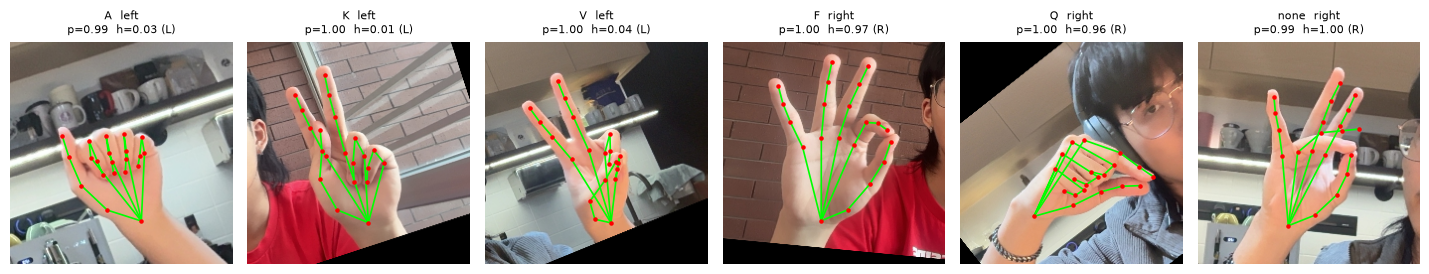

In [27]:
# --- Eyeball the capture: the skeleton has to sit on the hand ------------------------
# Nothing here runs a model: every number drawn comes out of the cache above, so a
# skeleton floating beside the hand means the two stages disagree about which square
# was cropped, not that the net missed. The crops are the detector's upright ones,
# which is why these skeletons stand up while the vectors above are tilted back.
import matplotlib.pyplot as plt

_rows = np.linspace(0, len(kept) - 1, SHOW).astype(int)
fig, axes = plt.subplots(1, SHOW, figsize=(2.4 * SHOW, 2.9))
for ax, row in zip(axes, _rows):
    i = kept[row]
    path, label, subset = ft_samples[i]
    pts = ft["kp"][i][:, :2] * IMG_SIZE          # cached 0-1 of the crop -> pixels
    ax.imshow(crop_roi(cv2.imread(str(path)), *ft["roi"][i], ft["deg"][i]))
    for finger in FINGERS:
        ax.plot(pts[list(finger), 0], pts[list(finger), 1], "-", lw=1.2, c="lime")
    ax.scatter(pts[:, 0], pts[:, 1], s=5, c="red", zorder=3)
    ax.set_title(f"{label}  {subset.split('/')[1]}\np={ft['presence'][i]:.2f}  "
                 f"h={ft['handed'][i]:.2f} "
                 f"({'L' if ft['handed'][i] < 0.5 else 'R'})", fontsize=8)
    ax.axis("off")
plt.tight_layout()

In [28]:
# --- The experiment MLP architecture and the fine-tune loop --------------------------
# The classifier of experiment_mlp.ipynb: Linear, BatchNorm, ReLU, Dropout per hidden
# layer, and a bare Linear head because CrossEntropyLoss wants raw logits.
#
# Fine-tuning must start from the exact all-images base checkpoint produced by the new
# experiment pipeline. It is deliberately not retrained here with a duplicate recipe.
import torch.nn as nn

WEIGHTS = Path("weights")
WEIGHTS.mkdir(exist_ok=True)
BASE_CKPT = WEIGHTS / f"{FEATURES}_mlp.pt"
if not BASE_CKPT.exists():
    raise FileNotFoundError(
        f"{BASE_CKPT} is missing; run experiment_mlp.ipynb first")
_BASE_SHAPES = torch.load(BASE_CKPT, map_location="cpu", weights_only=True)
_BASE_LINEAR = [value for name, value in _BASE_SHAPES.items()
                if name.endswith(".weight") and value.ndim == 2]
assert _BASE_LINEAR[-1].shape[0] == len(CLASSES), "base checkpoint is not A-Z"
HIDDEN = tuple(weight.shape[0] for weight in _BASE_LINEAR[:-1])
del _BASE_SHAPES, _BASE_LINEAR


def build_mlp(in_dim=IN_DIM, hidden=HIDDEN, n_classes=len(MODEL_CLASSES), dropout=DROPOUT):
    layers, prev = [], in_dim
    for width in hidden:
        layers += [nn.Linear(prev, width), nn.BatchNorm1d(width),
                   nn.ReLU(), nn.Dropout(dropout)]
        prev = width
    return nn.Sequential(*layers, nn.Linear(prev, n_classes))


def fit(model, X, y, X_val, y_val, lr, ckpt, epochs, desc=None, verbose=True):
    """Train `model`; the best val epoch's weights land in `ckpt` and are restored.

    The loop takes its learning rate, checkpoint and epoch ceiling explicitly so the
    base fallback and fine-tune can use different limits. Val accuracy gates both the
    decay and early stop. After each update pass, train and val are both measured in
    eval mode with the epoch's final weights, so their plotted curves are comparable.
    The whole split sits on DEVICE and a batch is an index slice, so an epoch costs no
    host transfer.
    """
    X, X_val = torch.from_numpy(X).to(DEVICE), torch.from_numpy(X_val).to(DEVICE)
    y, y_val = torch.from_numpy(y).to(DEVICE), torch.from_numpy(y_val).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=LR_DECAY, patience=LR_PATIENCE)

    def run_epoch(X, y, train):
        model.train(train)
        n = len(y)
        order = (torch.randperm(n, device=DEVICE) if train
                 else torch.arange(n, device=DEVICE))
        if train:                               # BatchNorm needs more than one row
            order = order[: (n // BATCH_SIZE) * BATCH_SIZE]
        loss_sum = correct = seen = 0.0
        with torch.set_grad_enabled(train):
            for start in range(0, len(order), BATCH_SIZE):
                idx = order[start:start + BATCH_SIZE]
                logits = model(X[idx])
                loss = criterion(logits, y[idx])
                if train:
                    optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    optimizer.step()
                loss_sum += loss.detach() * len(idx)
                correct += (logits.argmax(1) == y[idx]).sum()
                seen += len(idx)
        return (loss_sum / seen).item(), (correct / seen).item()

    history, best_acc, stale = [], -1.0, 0
    for epoch in tqdm(range(1, epochs + 1), desc=desc or ckpt.stem, unit="ep"):
        run_epoch(X, y, True)
        tr_loss, tr_acc = run_epoch(X, y, False)
        va_loss, va_acc = run_epoch(X_val, y_val, False)
        history.append((tr_loss, tr_acc, va_loss, va_acc))
        scheduler.step(va_acc)
        if va_acc > best_acc:
            best_acc, stale = va_acc, 0
            torch.save(model.state_dict(), ckpt)
        else:
            stale += 1
        if verbose and (epoch == 1 or epoch % 50 == 0 or epoch == epochs):
            print(f"{epoch:3d}  train {tr_loss:.4f} / {tr_acc:6.2%}   "
                  f"val {va_loss:.4f} / {va_acc:6.2%}   "
                  f"lr {optimizer.param_groups[0]['lr']:.2e}")
        if stale >= EARLY_STOP:
            if verbose:
                print(f"early stop at epoch {epoch} "
                      f"({EARLY_STOP} epochs without val improvement)")
            break
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    return np.array(history), best_acc


def predict(model, X, chunk=4096):
    """Model-class index per row, in row order, with the model in eval mode."""
    model.eval()
    with torch.no_grad():
        return torch.cat([
            model(torch.from_numpy(X[i:i + chunk]).to(DEVICE)).argmax(1).cpu()
            for i in range(0, len(X), chunk)]).numpy()


def load_pretrained_base(model, checkpoint):
    """Load A-Z weights; optionally append a suppressed, trainable `none` output."""
    source = torch.load(checkpoint, map_location=DEVICE, weights_only=True)
    if not INCLUDE_NONE:
        model.load_state_dict(source)
        return

    target = model.state_dict()
    head = str(len(model) - 1)
    expected_mismatch = {f"{head}.weight", f"{head}.bias"}
    mismatched = {name for name in source if source[name].shape != target[name].shape}
    if mismatched != expected_mismatch:
        raise ValueError(f"unexpected pretrained shape differences: {mismatched}")
    for name, value in source.items():
        if name not in expected_mismatch:
            target[name].copy_(value)
    target[f"{head}.weight"][:len(CLASSES)].copy_(source[f"{head}.weight"])
    target[f"{head}.bias"][:len(CLASSES)].copy_(source[f"{head}.bias"])
    target[f"{head}.weight"][len(CLASSES)].zero_()
    target[f"{head}.bias"][len(CLASSES)] = -10.0
    model.load_state_dict(target)


model = build_mlp().to(DEVICE)
load_pretrained_base(model, BASE_CKPT)
_mode = "27-class transfer initialization" if INCLUDE_NONE else "26-class fine-tune initialization"
print(f"{_mode} loaded from {BASE_CKPT}")

# The one fine-tune below always starts from these exact base weights rather than from
# whatever a previous execution left in `model`.
base_state = {name: p.clone() for name, p in model.state_dict().items()}

# What the base model scores on the test capture, before it has seen the new stills.
# This is the number the fine-tune has to beat, and it is the same one runs/2d+3d.npz
# holds, so a wide gap means BASE_CKPT is not the model that file was scored with.
base_hit = sure & (predict(model, X_test) == test_y)
print(f"\nbase model on the test capture: {base_hit.mean():.2%} of all frames, "
      f"{base_hit.sum() / sure.sum():.2%} of the confirmed")

27-class transfer initialization loaded from weights/2d+3d_mlp.pt

base model on the test capture: 75.48% of all frames, 86.50% of the confirmed


27-class transfer learning rows 4,370; confirmed validation_set rows 3,674


fine-tune:   0%|          | 1/300 [00:00<00:51,  5.80ep/s]

  1  train 0.6125 / 93.07%   val 0.3519 / 91.43%   lr 1.00e-04


fine-tune:   1%|          | 3/300 [00:00<00:46,  6.32ep/s]

fine-tune:  17%|█▋        | 51/300 [00:07<00:36,  6.81ep/s]

...

200  train 0.0001 / 100.00%   val 0.4256 / 92.76%   lr 1.00e-04


fine-tune:  84%|████████▎ | 251/300 [00:36<00:06,  7.52ep/s]

250  train 0.0002 / 100.00%   val 0.4140 / 93.11%   lr 1.00e-04


fine-tune: 100%|██████████| 300/300 [00:43<00:00,  6.89ep/s]


300  train 0.0000 / 100.00%   val 0.4658 / 92.71%   lr 1.00e-04
best epoch 88: train loss 0.0014 / acc 100.00%, val loss 0.3260 / acc 93.60%
trained 300 / 300 epochs; restored -> weights/2d+3d_finetune_ALL_NONE_1-100_mlp.pt


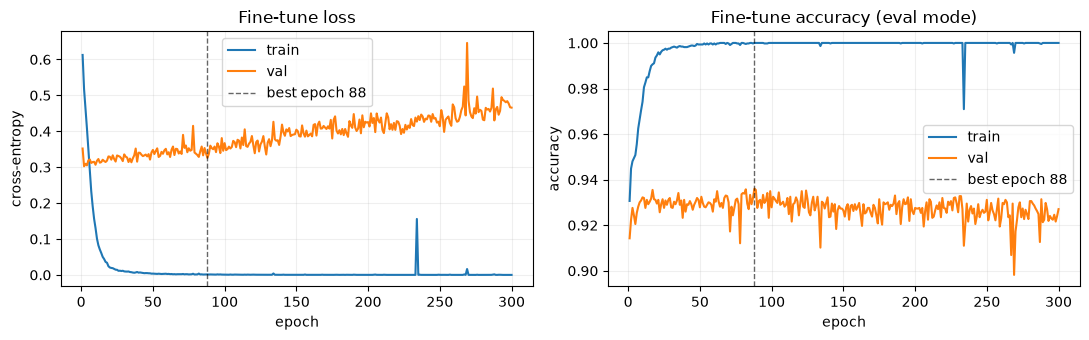

In [29]:
# --- Fine-tuning on every gated selected row, validated independently ----------------
# The test capture is never used for fitting or checkpoint selection. All gated
# TARGET_LETTERS 1-100 stills train the model; confirmed validation_set frames select
# the best epoch, and the final test still covers all 26 letters.
FT_CKPT = WEIGHTS / f"{FEATURES}_finetune_{TARGET_TAG}_mlp.pt"

torch.manual_seed(FINETUNE_SEED)
model = build_mlp().to(DEVICE)
model.load_state_dict(base_state)
assert set(np.unique(ft_kept_y[train_idx])) == set(TARGET_CLASS_INDICES)
_selection = ("27-class transfer learning" if INCLUDE_NONE else
              ("all-class fine-tuning" if TARGET_LETTERS == ALL_LETTERS else
               "targeted fine-tuning"))
print(f"{_selection} rows {len(train_idx):,}; "
      f"confirmed validation_set rows {base_val_sure.sum():,}")
hist, best_val = fit(
    model,
    X_ft[train_idx],
    ft_kept_y[train_idx],
    X_base_val[base_val_sure],
    y_base_val[base_val_sure],
    FT_LR,
    FT_CKPT,
    FINETUNE_EPOCHS,
    desc="fine-tune",
)
best_epoch = int(hist[:, 3].argmax()) + 1
best_train_loss, best_train_acc, best_val_loss, _ = hist[best_epoch - 1]

print(f"best epoch {best_epoch:,}: train loss {best_train_loss:.4f} / "
      f"acc {best_train_acc:.2%}, val loss {best_val_loss:.4f} / acc {best_val:.2%}")
print(f"trained {len(hist):,} / {FINETUNE_EPOCHS:,} epochs; restored -> {FT_CKPT}")

epochs = np.arange(1, len(hist) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(epochs, hist[:, 0], label="train")
axes[0].plot(epochs, hist[:, 2], label="val")
axes[0].set(title="Fine-tune loss", xlabel="epoch", ylabel="cross-entropy")
axes[1].plot(epochs, hist[:, 1], label="train")
axes[1].plot(epochs, hist[:, 3], label="val")
axes[1].set(title="Fine-tune accuracy (eval mode)", xlabel="epoch", ylabel="accuracy")
for ax in axes:
    ax.axvline(best_epoch, color="black", ls="--", lw=1, alpha=0.6,
               label=f"best epoch {best_epoch}")
    ax.grid(alpha=0.2)
    ax.legend()
plt.tight_layout()


3,744 frames, 144 of every letter, left and right
  palm found        3,480    92.95% of all
  hand confirmed    3,267    87.26% of all
  letter correct    2,948    78.74% of all   (base  75.48%, +3.26%)
                    2,948    90.24% of the confirmed   (base  86.50%)
  the hand filmed  left 72.28%   right 85.20%

per letter, out of 144 frames each, worst first
  N   palm  86%   hand  56%   correct  41%   base  34%   of confirmed  73%  ############
  Z   palm  80%   hand  72%   correct  58%   base  60%   of confirmed  80%  #################
  M   palm  94%   hand  88%   correct  64%   base  62%   of confirmed  72%  ###################
  J   palm  74%   hand  71%   correct  65%   base  63%   of confirmed  91%  ###################
  F   palm  67%   hand  66%   correct  65%   base  65%   of confirmed  98%  ###################
  T   palm  90%   hand  72%   correct  67%   base  62%   of confirmed  94%  ####################
  S   palm  97%   hand  87%   correct  68%   base  77%   of con

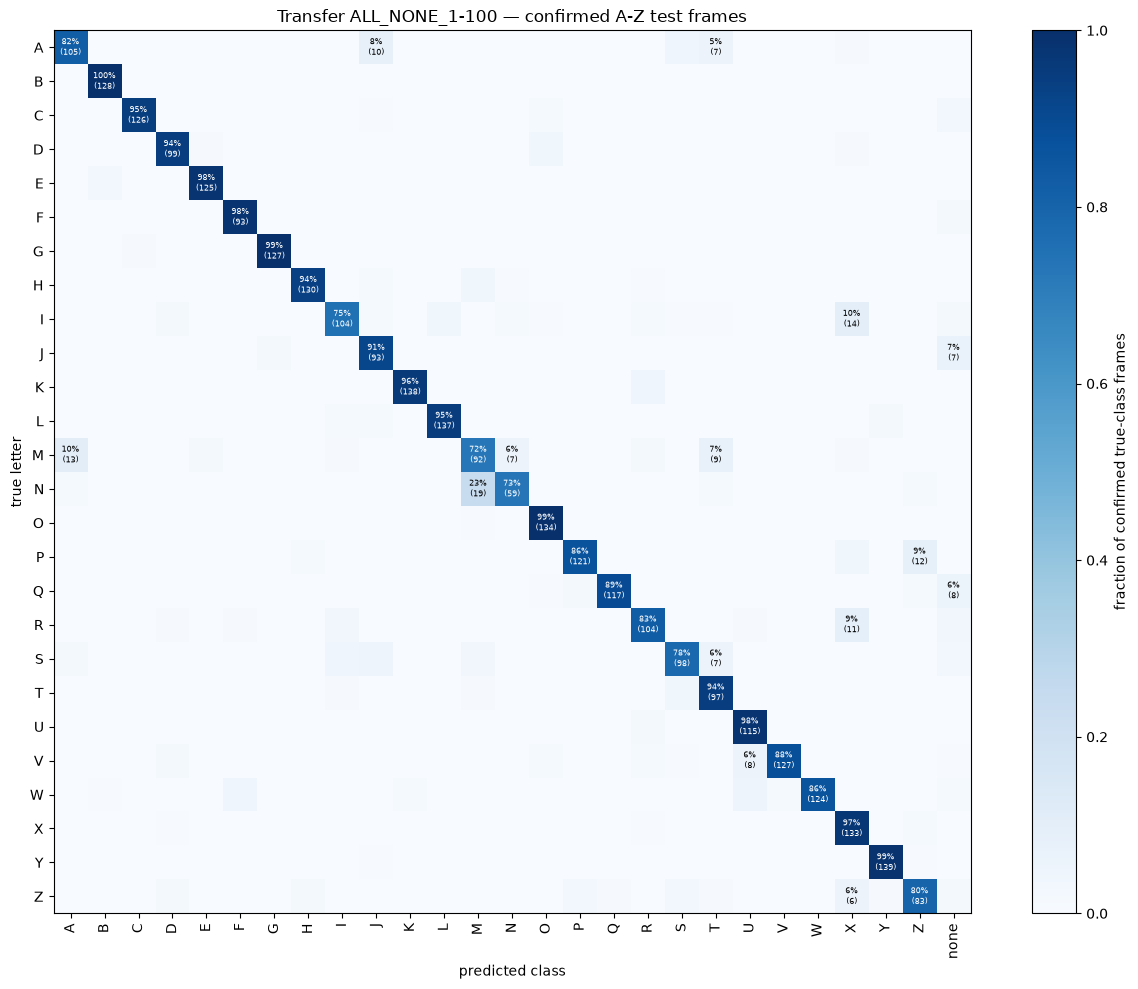

In [30]:
# --- Test: the same frames, the same gates, the same three numbers -------------------
# Straight out of experiment_mlp.ipynb. Every percentage is over every frame filmed,
# never over the survivors of the stage before, because a denominator that shrinks at
# each step is what lets a pipeline look accurate by answering less. The base model's
# score on these same frames is printed beside it: that difference is the whole point
# of the notebook. The separate validation_set selected the checkpoint; this independent
# test capture remains untouched until this final report.
import matplotlib.pyplot as plt

RUNS_DIR = Path("runs")     # one file per run, read by experiments.ipynb
RUN = f"finetune-{TARGET_TAG}+{FEATURES}"

val_pred = predict(model, X_base_val[base_val_sure])
pred = predict(model, X_test)
# A frame no hand was ever found in cannot be answered correctly, whatever the model
# happens to reply to the filler row standing in for it.
hit = sure & (pred == test_y)
n, each = len(test_y), np.bincount(test_y).min()
assert hit.sum() <= sure.sum() <= found.sum() <= n, "a stage passed on more than it got"

print(f"{n:,} frames, {each} of every letter, left and right")
print(f"  palm found       {found.sum():6,}   {found.mean():7.2%} of all")
print(f"  hand confirmed   {sure.sum():6,}   {sure.mean():7.2%} of all")
print(f"  letter correct   {hit.sum():6,}   {hit.mean():7.2%} of all"
      f"   (base {base_hit.mean():7.2%}, {hit.mean() - base_hit.mean():+.2%})")
# Same numerator, smaller denominator: the model marked only on the frames it was
# actually handed landmarks for, which is the classifier on its own with the detector's
# misses set aside. The line above is what a user would feel.
print(f"                   {hit.sum():6,}   {hit.sum() / sure.sum():7.2%} of the "
      f"confirmed   (base {base_hit.sum() / sure.sum():7.2%})")
print(f"  the hand filmed  left {hit[test_left].mean():.2%}   "
      f"right {hit[~test_left].mean():.2%}")

print(f"\nper letter, out of {each} frames each, worst first")
for h, b, f, s, name in sorted((hit[test_y == i].mean(), base_hit[test_y == i].mean(),
                                found[test_y == i].mean(), sure[test_y == i].mean(),
                                CLASSES[i]) for i in range(len(CLASSES))):
    print(f"  {name}   palm {f:4.0%}   hand {s:4.0%}   correct {h:4.0%}"
          f"   base {b:4.0%}   of confirmed {h / s if s else np.nan:4.0%}  "
          + "#" * round(h * 30))

# Classifier confusion only: detector-rejected frames remain in coverage metrics. In
# transfer mode, `none` is a real 27th row/column; validation/test contain no true-none
# samples, so its row is empty while false-none predictions appear in its column.
def normalized_confusion(y_true, y_pred):
    counts = np.zeros((len(MODEL_CLASSES), len(MODEL_CLASSES)), dtype=int)
    np.add.at(counts, (y_true, y_pred), 1)
    totals = counts.sum(axis=1, keepdims=True)
    rates = np.divide(counts, totals, out=np.zeros_like(counts, dtype=float),
                      where=totals > 0)
    return counts, rates


def draw_confusion(ax, counts, rates, title):
    image = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=1)
    ax.set(title=title, xlabel="predicted class", ylabel="true class")
    ax.set_xticks(np.arange(len(MODEL_CLASSES)), MODEL_CLASSES, rotation=90)
    ax.set_yticks(np.arange(len(MODEL_CLASSES)), MODEL_CLASSES)
    for true, predicted in zip(*np.where((rates >= 0.05) & (counts > 0))):
        rate = rates[true, predicted]
        ax.text(predicted, true, f"{rate:.0%}\n({counts[true, predicted]})",
                ha="center", va="center", fontsize=5.5,
                color="white" if rate < 0.12 or rate > 0.82 else "black")
    return image


val_confusion, val_confusion_rate = normalized_confusion(
    y_base_val[base_val_sure], val_pred
)
test_confusion, test_confusion_rate = normalized_confusion(test_y[sure], pred[sure])
_selection_title = ("Transfer" if INCLUDE_NONE else
                    ("All-class" if TARGET_LETTERS == ALL_LETTERS else "Targeted"))
fig, axes = plt.subplots(1, 2, figsize=(26 if INCLUDE_NONE else 25, 10),
                         layout="constrained")
images = [
    draw_confusion(
        axes[0], val_confusion, val_confusion_rate,
        f"{_selection_title} {TARGET_TAG} — confirmed validation frames",
    ),
    draw_confusion(
        axes[1], test_confusion, test_confusion_rate,
        f"{_selection_title} {TARGET_TAG} — confirmed test frames",
    ),
]
fig.colorbar(images[-1], ax=axes, shrink=0.82, pad=0.02).set_label(
    "fraction of confirmed true-class frames"
)
fig.suptitle("Row-normalized confusion: red = low, yellow = middle, green = high")
plt.show()

# Save this targeted run separately from the previous all-class fine-tune. A frame that
# never cleared the gates is saved as "-", not as whatever the model said, and the
# selected letters/range travel with the artifact so it cannot be mistaken for a full
# all-class adaptation later.
RUNS_DIR.mkdir(exist_ok=True)
np.savez(RUNS_DIR / f"{RUN}.npz",
         features=RUN, dims=IN_DIM, normalization="per-sample-minmax", image_depth=False,
         hidden=np.array(HIDDEN), dropout=DROPOUT,
         lr=FT_LR, batch_size=BATCH_SIZE, max_epochs=FINETUNE_EPOCHS,
         epochs=len(hist), history=hist, best_val=best_val, best_epoch=best_epoch,
         validation="validation_set-confirmed", finetune_seed=FINETUNE_SEED,
         transfer_learning=INCLUDE_NONE, include_none=INCLUDE_NONE,
         targeted=TARGET_LETTERS != ALL_LETTERS,
         model_classes=np.array(MODEL_CLASSES),
         fine_tune_letters=np.array(TARGET_LETTERS),
         fine_tune_classes=np.array(SELECTED_CLASSES),
         image_number_min=VALID_IMAGE_NUMBERS.start,
         image_number_max=VALID_IMAGE_NUMBERS.stop - 1,
         train_rows=len(train_idx), val_rows=int(base_val_sure.sum()),
         base_all=base_hit.mean(),
         val_y_true=np.array(CLASSES)[y_base_val[base_val_sure]],
         val_y_pred=np.array(MODEL_CLASSES)[val_pred],
         y_true=np.array(CLASSES)[test_y],
         y_pred=np.where(sure, np.array(MODEL_CLASSES)[pred], "-"),
         palm=test_palm, presence=test_presence, left=test_left)
print(f"\nsaved -> {RUNS_DIR / f'{RUN}.npz'}")